<a href="https://colab.research.google.com/github/rkaykothari-maker/ores5160-2026/blob/main/Copy_of_week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


In [ ]:
import csv
import requests
from io import StringIO

url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv"

data = requests.get(url).text

reader = csv.reader(StringIO(data))

for i, row in enumerate(reader):
    print(row)
    if i == 4:
        break

['date', 'state', 'fips', 'cases', 'deaths']
['2020-01-21', 'Washington', '53', '1', '0']
['2020-01-22', 'Washington', '53', '1', '0']
['2020-01-23', 'Washington', '53', '1', '0']
['2020-01-24', 'Illinois', '17', '1', '0']


In [ ]:
import pandas as pd

csv_url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv"

df = pd.read_csv(csv_url)

df.head()

,date,state,fips,cases,deaths
0,2020-01-21,Washington,53,1,0
1,2020-01-22,Washington,53,1,0
2,2020-01-23,Washington,53,1,0
3,2020-01-24,Illinois,17,1,0
4,2020-01-24,Washington,53,1,0


In [ ]:
print("Shape:", df.shape)

Shape: (61942, 5)


In [ ]:
print("Columns:", df.columns)

Columns: Index(['date', 'state', 'fips', 'cases', 'deaths'], dtype='object')


In [ ]:
df.sort_values("cases", ascending=False).head(5)

,date,state,fips,cases,deaths
61891,2023-03-23,California,6,12169158,104277
61835,2023-03-22,California,6,12155467,104196
61779,2023-03-21,California,6,12154941,104185
61723,2023-03-20,California,6,12154293,104165
61667,2023-03-19,California,6,12153083,104130


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

In [ ]:
average_cases = df["cases"].mean()

print("Average population (cases):", average_cases)

Average population (cases): 889830.0696135095


In [ ]:
state_population = df.groupby("state")["cases"].sum()

print("State with highest population:", state_population.idxmax())

State with highest population: California


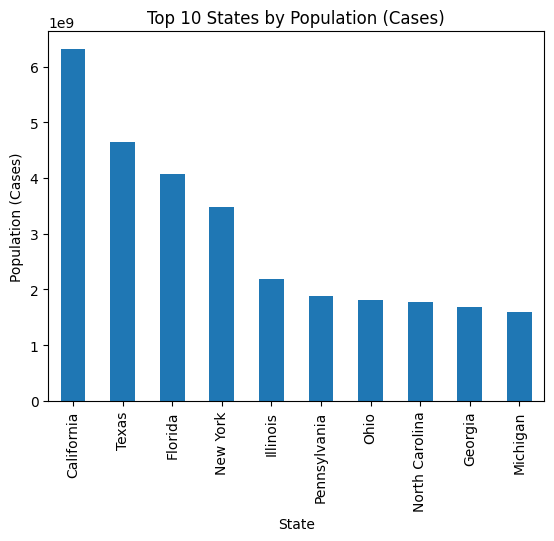

In [ ]:
import matplotlib.pyplot as plt

state_population.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 States by Population (Cases)")
plt.xlabel("State")
plt.ylabel("Population (Cases)")

plt.show()

Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

In [ ]:
import requests

url = "https://raw.githubusercontent.com/gajen0981/Sample-FHIR-Data/master/HL7/Patient.json"
patient = requests.get(url).json()

print(type(patient))

<class 'dict'>


In [ ]:
for name in patient["name"]:
    if name["use"] == "official":
        given = " ".join(name["given"])
        family = " ".join(name["family"])
        full_name = given + " " + family
        print("Official Name:", full_name)

Official Name: Peter James Chalmers


In [ ]:
gender = patient["gender"]["coding"][0]["display"]
birth_date = patient["birthDate"]

print("Gender:", gender)
print("Birth Date:", birth_date)

Gender: Male
Birth Date: 1974-12-25


In [ ]:
address = patient["address"][0]

print("City:", address["city"])
print("State:", address["state"])
print("Postal Code:", address["zip"])

City: PleasantVille
State: Vic
Postal Code: 3999


In [ ]:
phone_types = []

for contact in patient["telecom"]:
    if contact.get("system") == "phone":
        phone_types.append(contact.get("use", "unknown"))

print("Number of phone numbers:", len(phone_types))
print("Phone types:", phone_types)

Number of phone numbers: 1
Phone types: ['work']
